<a href="https://colab.research.google.com/github/Roshni-AngelAlex/DEEP-LEARNING/blob/main/24BAD101(DEEP_LEARNING).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DEEP LEARNING**

**24ADI006**

**Perceptron Implementation**


ROSHNI ANGEL A

24BAD101

**Worksheet 1**

TASK 1 : AND GATE

AND Gate Predictions
[0 0]  -->  0
[0 1]  -->  0
[1 0]  -->  0
[1 1]  -->  1

AND Accuracy : 100.0 %


TASK 1 : OR GATE

OR Gate Predictions
[0 0]  -->  0
[0 1]  -->  1
[1 0]  -->  1
[1 1]  -->  1

OR Accuracy : 100.0 %


TASK 2 : RANDOM DATASET

Model Accuracy : 99.5 %


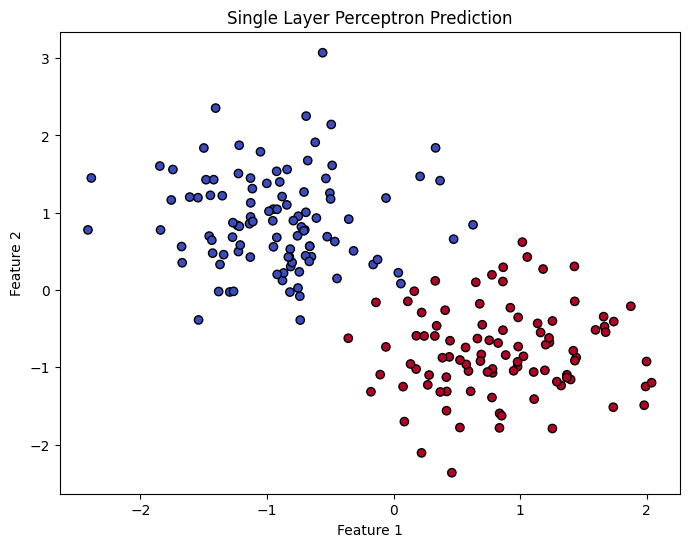

In [1]:
# Single Layer Perceptron Implementation


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# SINGLE LAYER PERCEPTRON CLASS
class Perceptron:

    def __init__(self, num_inputs, learning_rate=0.01):
        self.weights = np.random.randn(num_inputs + 1)
        self.learning_rate = learning_rate

    # Linear Layer
    def linear(self, inputs):
        return np.dot(inputs, self.weights[1:]) + self.weights[0]

    # Activation Function
    def heaviside(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    # Prediction
    def predict(self, inputs):

        if np.ndim(inputs) == 1:
            return self.heaviside(self.linear(inputs))

        predictions = []

        for x in inputs:
            predictions.append(self.heaviside(self.linear(x)))

        return np.array(predictions)

    # Loss
    def loss(self, prediction, target):
        return target - prediction

    # Training
    def train(self, inputs, target):

        prediction = self.predict(inputs)

        error = self.loss(prediction, target)

        self.weights[1:] += self.learning_rate * error * inputs
        self.weights[0] += self.learning_rate * error

    # Fit Model
    def fit(self, X, y, epochs=100):

        for epoch in range(epochs):

            for inputs, target in zip(X, y):

                self.train(inputs, target)


# TASK 1
# IMPLEMENT AND GATE

print("="*60)
print("TASK 1 : AND GATE")
print("="*60)

X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

perceptron_and = Perceptron(num_inputs=2, learning_rate=0.1)

perceptron_and.fit(X_and, y_and, epochs=20)

pred_and = perceptron_and.predict(X_and)

print("\nAND Gate Predictions")

for x,p in zip(X_and,pred_and):
    print(x," --> ",p)

accuracy_and = np.mean(pred_and == y_and)

print("\nAND Accuracy :", accuracy_and*100,"%")


# TASK 1
# IMPLEMENT OR GATE

print("\n")
print("="*60)
print("TASK 1 : OR GATE")
print("="*60)

X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

perceptron_or = Perceptron(num_inputs=2, learning_rate=0.1)

perceptron_or.fit(X_or, y_or, epochs=20)

pred_or = perceptron_or.predict(X_or)

print("\nOR Gate Predictions")

for x,p in zip(X_or,pred_or):
    print(x," --> ",p)

accuracy_or = np.mean(pred_or == y_or)

print("\nOR Accuracy :", accuracy_or*100,"%")


# TASK 2
# RANDOM DATASET

print("\n")
print("="*60)
print("TASK 2 : RANDOM DATASET")
print("="*60)

X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=2.5,
    random_state=42
)

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Train Model

model = Perceptron(
    num_inputs=2,
    learning_rate=0.01
)

model.fit(
    X_train,
    y_train,
    epochs=100
)

# Prediction

pred = model.predict(X_test)

# Accuracy

accuracy = np.mean(pred == y_test)

print("\nModel Accuracy :", round(accuracy*100,2),"%")


# VISUALIZATION

plt.figure(figsize=(8,6))

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=pred,
    cmap='coolwarm',
    edgecolor='k'
)

plt.title("Single Layer Perceptron Prediction")

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.show()